In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For better visuals
sns.set(style="whitegrid")

In [140]:
df = pd.read_csv(r"C:\Users\abuba\Downloads\archive(1)\WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [141]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

df.info()

Shape: (7043, 21)

Columns:
 Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   Internet

In [142]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [143]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [144]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [145]:
df = df.dropna()
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [146]:
df.shape

(7032, 21)

In [147]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

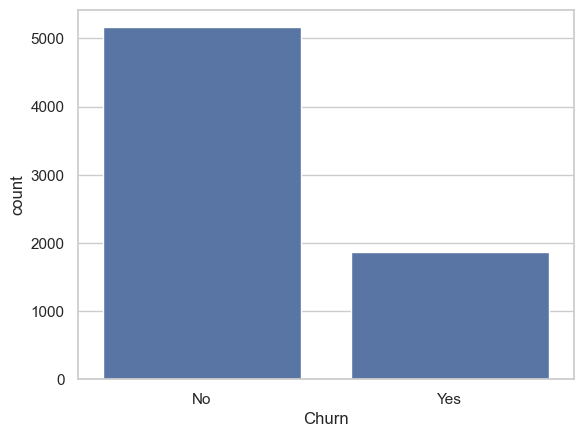

In [148]:
sns.countplot(x='Churn', data=df)
plt.show()

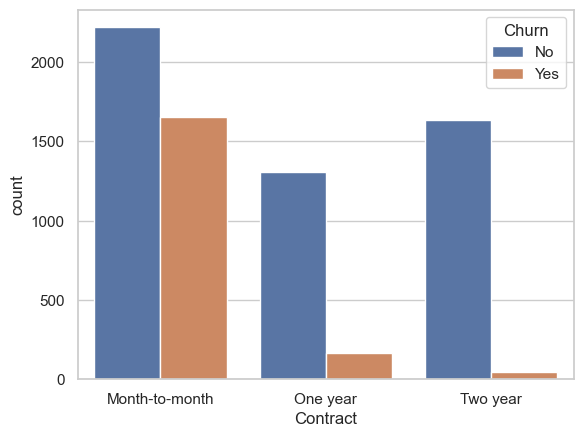

In [149]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.show()

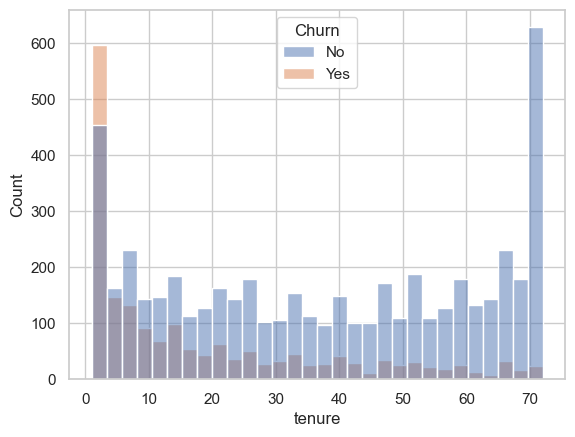

In [150]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=30)
plt.show()

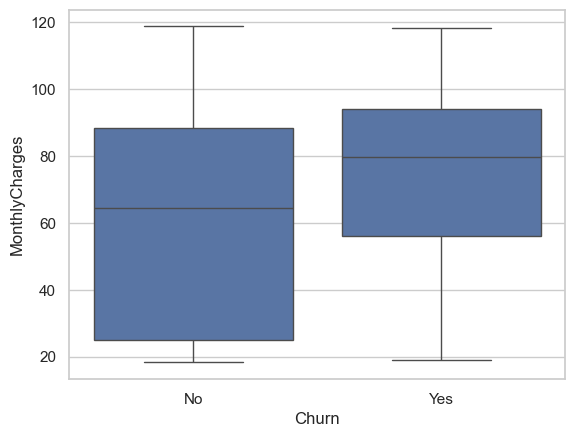

In [151]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

In [152]:
df['tenure_group'] = pd.cut(df['tenure'],
                           bins=[0, 12, 24, 48, 72],
                           labels=['0-1yr', '1-2yr', '2-4yr', '4-6yr'])

In [153]:
df['HighCharges'] = df['MonthlyCharges'] > df['MonthlyCharges'].median()

In [154]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [155]:
# customerID is just an identifier → not useful for prediction
df = df.drop('customerID', axis=1)

In [156]:
# Convert all categorical columns into dummy/one-hot encoded variables
df = pd.get_dummies(df, drop_first=True)

In [157]:
# Separate input features and target variable
X = df.drop('Churn', axis=1)  # Features
y = df['Churn']               # Target

In [158]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [159]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit on training data and transform both train & test
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [160]:
from sklearn.linear_model import LogisticRegression

# Initialize model with class balancing
# This gives more importance to minority class (churn = 1)
model = LogisticRegression(max_iter=1000, class_weight='balanced')

# Train model
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [161]:
# Predict churn (0 or 1)
y_pred = model.predict(X_test)

# Predict probabilities (important for later stages)
y_prob = model.predict_proba(X_test)[:, 1]

In [162]:
from sklearn.metrics import classification_report, confusion_matrix

# Confusion Matrix
print(confusion_matrix(y_test, y_pred))

# Classification Report
print(classification_report(y_test, y_pred))

[[733 300]
 [ 77 297]]
              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



In [163]:
# Create risk categories from probabilities
def risk_category(prob):
    if prob < 0.3:
        return "Low Risk"
    elif prob < 0.7:
        return "Medium Risk"
    else:
        return "High Risk"

# Apply to predictions
risk_labels = [risk_category(p) for p in y_prob]

In [164]:
# Create a results dataframe using test data
results = pd.DataFrame()

# Actual churn (ground truth)
results['Actual_Churn'] = y_test.values

# Predicted churn (0 or 1)
results['Predicted_Churn'] = y_pred

# Churn probability
results['Churn_Probability'] = y_prob

# Risk category
results['Risk_Level'] = risk_labels

In [165]:
results.head()

,Actual_Churn,Predicted_Churn,Churn_Probability,Risk_Level
0,0,0,0.026142,Low Risk
1,0,0,0.215643,Low Risk
2,1,1,0.815674,High Risk
3,0,0,0.261373,Low Risk
4,0,1,0.609992,Medium Risk


In [166]:
results['Risk_Level'].value_counts()

Risk_Level
Low Risk       596
Medium Risk    486
High Risk      325
Name: count, dtype: int64

In [167]:
# Function to generate explanation and recommendation
def generate_explanation(prob, risk):
    
    if risk == "High Risk":
        return "Customer is likely to churn. Recommend offering discounts or personalized retention plans."
    
    elif risk == "Medium Risk":
        return "Customer shows moderate churn risk. Recommend engagement campaigns or service improvements."
    
    else:
        return "Customer is stable. Maintain current service quality and satisfaction."

In [168]:
# Generate explanations for each customer
results['Recommendation'] = [
    generate_explanation(p, r) for p, r in zip(results['Churn_Probability'], results['Risk_Level'])
]

In [169]:
results.head()

,Actual_Churn,Predicted_Churn,Churn_Probability,Risk_Level,Recommendation
0,0,0,0.026142,Low Risk,Customer is stable. Maintain current service q...
1,0,0,0.215643,Low Risk,Customer is stable. Maintain current service q...
2,1,1,0.815674,High Risk,Customer is likely to churn. Recommend offerin...
3,0,0,0.261373,Low Risk,Customer is stable. Maintain current service q...
4,0,1,0.609992,Medium Risk,Customer shows moderate churn risk. Recommend ...


In [170]:
import pickle

# Save trained model
pickle.dump(model, open("model.pkl", "wb"))

# Save scaler
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [171]:
# ==============================
# Save feature columns for app
# ==============================

feature_columns = X.columns

import pickle
pickle.dump(feature_columns, open("features.pkl", "wb"))